# Backward and Forward Tracking of S-MODE IOP-2 Water Parcels
### Associated publication: Gangrade et al. (2026), GRL
### Survey: NASA S-MODE IOP-2
### Authors: Shailja Gangrade, Élise Beaudin, Mara Freilich
### Last updated: August 2026
#### Description: Plot forward-in-time trajectory pathlines (pathlines generated using high-frequency radar surface currents using Euler method) Plot background satellite-derived Chl-a. Plot backward-in-time trajectories of S-MODE IOP-2 water parcels using AVISO and GLORYS data.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd
import scipy
import scipy.io
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import gsw
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

def smode_pgon(ax):
    from matplotlib.patches import Polygon
    vertices = np.array([[-126.25, 38.342],[-123.99, 37.707],[-123.354, 37.75], [-122.92, 37.00],
                     [-124.36, 36.337],[-124.16, 36.00],[-125.515, 35.60]])
    polygon = Polygon(vertices, closed=True, edgecolor='k', linewidth=2, facecolor='none')
    ax.add_patch(polygon)

In [2]:
# load dataset
ds = xr.open_dataset('forward_tracking_2023-04-01T00_2023-04-15T002.nc') # Run save_forward_tracking.py to generate data file.
ds

<xarray.Dataset> Size: 232MB
Dimensions:   (seed: 31, time: 337, lat: 367, lon: 234)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2023-04-01 ... 2023-04-15
    time_run  (time) datetime64[ns] 3kB ...
  * seed      (seed) int64 248B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29 30
  * lat       (lat) float64 3kB 30.25 30.3 30.36 30.41 ... 49.88 49.94 49.99
  * lon       (lon) float64 2kB -130.4 -130.3 -130.2 ... -115.9 -115.9 -115.8
Data variables:
    lat_seed  (seed) float64 248B ...
    lon_seed  (seed) float64 248B ...
    lat_fwrd  (seed, time) float64 84kB ...
    lon_fwrd  (seed, time) float64 84kB ...
    u         (time, lat, lon) float32 116MB ...
    v         (time, lat, lon) float32 116MB ...

In [3]:
def write_time(time):
    YYYY=int(time.dt.year)
    MM=int(time.dt.month)
    DD=int(time.dt.day)
    return f'{YYYY}-{MM:02d}-{DD:02d}'

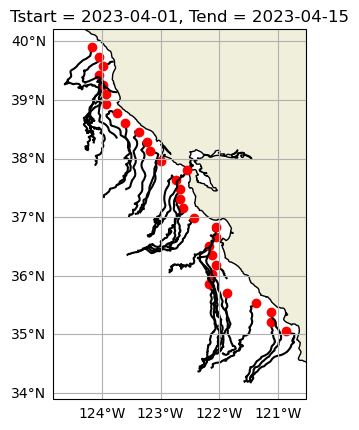

In [4]:
## Plot trajectories on map

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
#ax.set_extent([-125, -120, 34, 40], crs=ccrs.PlateCarree())
#ax.set_extent([-124.5, -124, 38, 39], crs=ccrs.PlateCarree())

for i in range(len(ds.seed)):
    ids=ds.isel(seed=i)
    ax.plot(ids.lon_fwrd,ids.lat_fwrd,'-k')
    ax.plot(ids.lon_seed,ids.lat_seed,'or')

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
gl=ax.gridlines(draw_labels=True)
gl.top_labels = False; gl.right_labels = False
plt.title(f'Tstart = {write_time(ds.time[0])}, Tend = {write_time(ds.time[-1])}')
plt.show()

In [5]:
## Load 16S sample metadata
metadata16S = pd.read_csv('SMODE_IOP1_IOP2_16S_metadata_wCTDvars.csv')
# print(metadata16S)
## Load bottle sample data
btl_IOP2 = pd.read_csv('IOP2-surface-bottledata-with-TSG.csv')
#print(btl_IOP2)

## Select only rows where 'year' is 2023 (IOP-2)
metadata16S_IOP2 = metadata16S[metadata16S['year'] == 2023] 
metadata16S_IOP2 = metadata16S_IOP2.reset_index(drop=True)
#print(metadata16S_IOP2)

## Select only rows where 'day' is April 18 thru 23 (IOP-2 eddy sampling only)
## Right now, only selecting bottle samples from flow-through ('niskin' == 0)
metadata16S_eddy = metadata16S_IOP2[(metadata16S_IOP2['day'] > 18) & (metadata16S_IOP2['day'] < 25) & (metadata16S_IOP2['niskin'] == 0)]
metadata16S_eddy = metadata16S_eddy.reset_index(drop=True)
#print(metadata16S_eddy)

# Now, we extract the station lons and lats for intializing the particles
stn_lats, stn_lons = metadata16S_eddy.lat, metadata16S_eddy.lon
btlstn_lats, btlstn_lons = btl_IOP2.latitude, btl_IOP2.longitude

## Reformat dates
# date_array = metadata16S_eddy.UTCDatetime.astype(str).to_list()
date_array = metadata16S_eddy.UTCDatetime.astype(str).to_list()
date_array_btl = btl_IOP2.date_dt.astype(str).to_list()

#print(date_array)

## Reformat dates from 16S metadata
original_format = "%m/%d/%Y %H:%M:%S"
new_format = "%Y-%m-%d"

stn_dates = []
for date_str in date_array:
    datetime_obj = datetime.strptime(date_str, original_format)
    datetime_obj = datetime_obj.strftime(new_format)
    stn_dates.append(datetime_obj)

## Now, we have the station sampling dates for intializing the particles
#print(stn_dates)

## Reformat dates from Bottle Data metadata
original_format_btl = "%d-%b-%Y"
new_format_btl = "%Y-%m-%d"

btl_stn_dates = []
for date_str in date_array_btl:
    datetime_obj = datetime.strptime(date_str, original_format_btl)
    datetime_obj = datetime_obj.strftime(new_format_btl)
    btl_stn_dates.append(datetime_obj)

## Now, we have the station sampling dates for intializing the particles
#print(btl_stn_dates)

In [6]:
metadata16S

,ID,year,cast,niskin,UTCDatetime,localTime,day,lon,lat,depth,...,chl,chl_fl,POC,chl_btl,phaeo,POC_btl,PON,PO4,SiO4,NO3
0,20221014_smode1_C1N1_16S.exp.,2022,1,1,10/14/2022 17:52:00,0.744444,14.0,-124.565600,37.025900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20221014_smode1_C1N10_16S.exp.,2022,1,10,10/14/2022 17:52:00,0.744444,14.0,-124.565600,37.025900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20221014_smode1_C1N2_16S.exp.,2022,1,2,10/14/2022 17:52:00,0.744444,14.0,-124.565600,37.025900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20221014_smode1_C1N4_16S.exp.,2022,1,4,10/14/2022 17:52:00,0.744444,14.0,-124.565600,37.025900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20221014_smode1_C1N7_16S.exp.,2022,1,7,10/14/2022 17:52:00,0.744444,14.0,-124.565600,37.025900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,221027_smode1_B88_16S.exp.,2022,88,0,10/27/2022 20:48:02,0.866700,27.0,-123.961413,36.622570,5.0,...,0.980607,0.132601,2.923888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
456,221027_smode1_B89_16S.exp.,2022,89,0,10/27/2022 20:52:56,0.870100,27.0,-123.958891,36.614597,5.0,...,0.980730,0.132601,2.904649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457,221027_smode1_B90_16S.exp.,2022,90,0,10/27/2022 21:15:59,0.886100,27.0,-123.946668,36.577288,5.0,...,0.984514,0.133969,3.127555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
458,blank.16S.exp.,2023,0,0,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
btl_IOP2

,latitude,longitude,depth,date_dt,time_dt,sal_abs,temp,sigma_T,chl_ug_L,phaeo_ug_L,poc_ug_L,pon_ug_L,nitrate_umol_L,silicate_umol_L
0,37.111427,-123.881969,0,11-Apr-2023,11-Apr-2023 16:00:00,32.717251,12.303,24.640,1.00,0.07,NaN,NaN,0.5365,1.9760
1,37.150702,-123.904355,0,11-Apr-2023,11-Apr-2023 16:30:00,32.742373,12.287,24.662,0.58,0.72,8.3053,1.291985,0.4220,1.3455
2,37.188517,-123.925855,0,11-Apr-2023,11-Apr-2023 16:58:00,32.775533,12.016,24.739,1.11,0.08,7.7365,1.097107,0.8560,1.8760
3,37.251176,-123.961604,0,11-Apr-2023,11-Apr-2023 17:30:00,32.682098,12.059,24.659,0.82,0.27,10.0401,1.503465,0.8990,2.5205
4,37.305816,-123.992783,0,11-Apr-2023,11-Apr-2023 17:58:00,32.655980,12.118,24.628,0.63,0.17,8.1659,1.259901,0.9350,2.2665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,36.839826,-125.279457,0,30-Apr-2023,30-Apr-2023 06:55:00,33.092940,13.095,24.777,0.24,0.11,NaN,NaN,NaN,NaN
146,36.816675,-125.480230,0,30-Apr-2023,30-Apr-2023 22:47:00,32.988437,12.979,24.719,0.32,0.15,2.1669,0.352397,NaN,NaN
147,36.816689,-125.457070,0,30-Apr-2023,30-Apr-2023 22:58:00,32.934182,12.394,24.790,0.34,0.16,2.6983,0.458942,NaN,NaN
148,36.816650,-125.440740,0,30-Apr-2023,30-Apr-2023 23:06:00,32.733236,12.861,24.545,1.04,0.17,8.7584,1.139673,NaN,NaN


In [8]:
# Load Chl-a data.
chl = xr.open_dataset('chla-2023.nc').chlor_a
chl = chl.sel(lat=slice(30,50),lon=slice(-130,-121))
chl = chl.rolling(time=8, min_periods=1).mean() #8-days rolling average
chl=chl.where((chl.lon<-123) | (chl.lat <38.1), drop=True) #remove land data

# Load Pacific Coastline 
mat = scipy.io.loadmat('WorldCstLinePacific.mat')['cst']
clat,clon = mat['lat'][0][0], mat['lon'][0][0]

## HF radar tracking

In [11]:
# Remove center 'white' color value from diverging color map and save new color map.

# Get original cmocean diverging colormap
orig_cmap = cmocean.cm.delta

# Extract color values (256 samples)
extracted_colors = orig_cmap(np.linspace(0, 1, 256))

# Define how much of the white center to cut out (e.g., skip index 118 to 138)
    # Lower number removes more from the start side, higher number from the end side of the center
lower_end = 115
upper_end = 141
new_colors = np.vstack((extracted_colors[:lower_end], extracted_colors[upper_end:]))

# Create the new custom colormap
no_white_cmap = colors.LinearSegmentedColormap.from_list(
    "delta_no_white", new_colors)

#####################################################
# Define your limits and desired pivot/center point
vmin, vmax = 1e-1, 30
pivot_point = 12.2  # Where the center/neutral color of the colormap should land, If you change vmin/vmax, you need to tune this value.

# Crop the already modified cmocean colormap using your pivot point
# diverging_cmap = cmocean.cm.curl  # or delta, balance, etc.
adjusted_no_white_cmap = cmocean.tools.crop(no_white_cmap, vmin, vmax, pivot=pivot_point)

# Apply LogNorm with matching vmin and vmax
log_norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# Sample code to plot the data
# fig, ax = plt.subplots()
# mappable = ax.pcolormesh(data, cmap=adjusted_cmap, norm=log_norm)
# fig.colorbar(mappable, ax=ax)
# plt.show()

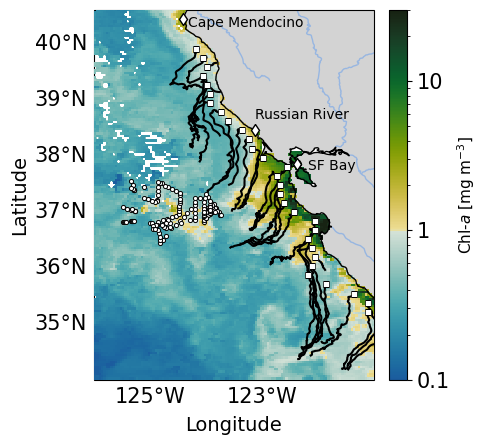

In [28]:
## NEW - August 2026. Plot trajectories on Chl-a map (different color map) with Bottle Sampling Locations - highlighted for eddy samples. 

# Load a cmocean colormap
# cmoce_cmap = cmocean.cm.speed

# Set up map projection (US West Coast)
# fig = plt.figure(figsize=(8, 10))
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
## Identify axes extents.
lonmin,lonmax,latmin,latmax = -126,-121,34,40.6
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

# Add geographic land and coastline layers
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=5)
ax.add_feature(cfeature.RIVERS, linewidth=1, zorder=2)
# ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=3) # enable if showing more than just California land.

# Plot natural-unit Chl data using LogNorm (10^-2 to 10^1)
date='2023-04-15'; chlmin = 1.2 # Identify Chl date
p=ax.contourf(chl.lon,chl.lat,np.log10(chl.sel(time=date)),50,vmin=-2,vmax=2,cmap=cmocean.cm.delta)
# pcm = ax.pcolormesh(
#     chl.lon, chl.lat, chl.sel(time=date),
#     norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
#     cmap=cmoce_cmap,
#     transform=ccrs.PlateCarree(),
#     zorder=1
# )

pcm = ax.pcolormesh(
    chl.lon, chl.lat, chl.sel(time=date),
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    zorder=3
)

## Plot forward trajectories from HFR analysis.
for i in range(len(ds.seed)):
    ids=ds.isel(seed=i)
    ax.plot(ids.lon_fwrd,ids.lat_fwrd,'-k',zorder=5)
    ax.plot(ids.lon_seed,ids.lat_seed,
            marker='s',               # Shape: 's' for square
            color='white',
            # color='blue',             # Color of the connecting line
            # markerfacecolor='white',    # Color of the inside of the marker
            markeredgecolor='black',  # Color of the marker border
            markeredgewidth=0.5,
            markersize=4,
           zorder=6)  


# Plot bottle sampling locations.
stns = ax.scatter(btl_IOP2.longitude,btl_IOP2.latitude,s=9, c="white",edgecolors = "black",lw=0.7,zorder=7)

## Add ROI locations (Russian River and SF Bay)
RR = [38.450159, -123.130602] # Russian River
SF = [37.840524, -122.379691] # SF Bay
CM = [40.438594, -124.413537] # Cape Mendocino

box_props = dict(boxstyle='square', facecolor='white', edgecolor='none') ##white box behind text labels

ax.plot(RR[1],RR[0],'dw',markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8);
ax.text(RR[1],RR[0]+0.2,'Russian River',fontsize=10, transform=ccrs.PlateCarree(), zorder=8)
ax.plot(SF[1],SF[0],'dw',markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8);
ax.text(SF[1]+0.2,SF[0]-0.1,'SF Bay',fontsize=10, transform=ccrs.PlateCarree(), zorder=8)
ax.plot(CM[1],CM[0],'dw',markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8);
ax.text(CM[1]+0.1,CM[0]-0.15,'Cape Mendocino',fontsize=10,transform=ccrs.PlateCarree(), zorder=8)

# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, color='none', linestyle='None')
gl.top_labels = False; gl.right_labels = False

# Label for the bottom X-axis
ax.text(0.5, -0.15, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.30, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

##################


##Save figure 
# plt.savefig('HFR_forwardtrack_chlmap_surfbtlsamples.png',dpi=600,bbox_inches='tight', pad_inches=0)

plt.show()

## AVISO and GLORYS Tracking

In [17]:
# Set extents
lonmin,lonmax,latmin,latmax = -130,-121,33,40
T0,T1 = '2023-01-01','2023-05-02'

# Load GLORYS data
glorys = xr.open_dataset('cmems_glorys.nc')
#glorys = glorys.sel(latitude=slice(latmin,latmax),longitude=slice(lonmin,lonmax))
u083,v083 = glorys.uo[:,0,...], glorys.vo[:,0,...]

# Load AVISO+EKMAN data
copern = xr.open_dataset('cmems_aviso_ekman.nc')
copern = copern.sel(latitude=slice(latmin,latmax),
                    longitude=slice(lonmin,lonmax))
u025,v025 = copern.uo[:,0,...], copern.vo[:,0,...]

# Load Chl-a data
chl = xr.open_dataset('chla-2023.nc').chlor_a
chl = chl.sel(lat=slice(30,50),lon=slice(-130,-121))
chl = chl.rolling(time=8, min_periods=1).mean() #8-days rolling average
chl=chl.where((chl.lon<-123) | (chl.lat <38.1), drop=True) #remove land data

# Load Pacific Coastline 
mat = scipy.io.loadmat('WorldCstLinePacific.mat')['cst']
clat,clon = mat['lat'][0][0], mat['lon'][0][0]

# Load CUTI index
CUTI = xr.open_dataset('CUTI_daily2.nc')

In [18]:
# Simple backtracking advection model:

def particle_backtrack(lat,lon,u,v):

    #index = u['time'].to_index().get_loc(t0)
    #T = u.timeindex#.start
    T = u.shape[0]
    u,v = u.isel(time=slice(0,T)), v.isel(time=slice(0,T))
    
    dt = 3600*24 # time resolution of velocity data (1 day) [s]
    
    lat_back = np.empty([T])*np.nan
    lon_back = np.empty([T])*np.nan
    
    lat_back[0] = lat
    lon_back[0] = lon
    
    # backward velocities
    for i in range(T-1):
        # velocity at parcel location
        u_back = u[T-i-1,...].sel(latitude=lat_back[i], longitude=lon_back[i], method='nearest')
        v_back = v[T-i-1,...].sel(latitude=lat_back[i], longitude=lon_back[i], method='nearest')
    
        # compute displacement
        dx = u_back*dt
        dy = v_back*dt # distance traveled (meters)
    
        # convert into degrees
        dlat = dy / 111320.
        dlon = dx / (np.cos(np.deg2rad(lat_back[i])) * 111320.)
        
        # new position
        lat_new = lat_back[i]-dlat
        lon_new = lon_back[i]-dlon
        
        # save output
        lat_back[i+1] = lat_new
        lon_back[i+1] = lon_new

    return lat_back, lon_back

def find_transit_time(v,lat_back,lon_back,dist_to_coast=1/12):
    # dist_to_coast = 1/12 #degree
    # return transit time in units of the data
    N = len(lat_back)
    
    # find when it hits the coast
    u_c=np.empty([N])
    for i in range(N):
        u_c[i] = v.isel(time=i).sel(latitude=lat_back[i]+dist_to_coast, 
                    longitude=lon_back[i]+dist_to_coast, 
                    method='nearest')
    
    if (np.isnan(u_c)).sum()>0: #touches the coast
        transit_time = np.where(np.isnan(u_c)==True)[0][0]
    else: transit_time = N
    
    return int(transit_time)

def smooth_track(lat_back,lon_back):
    from scipy.interpolate import interp1d
    if len(lat_back)==1:
        new_lat,new_lon = lat_back, lon_back
    if len(lat_back)<=3:
        new_lat = np.linspace(lat_back[0], lat_back[-1], 1000)
        new_lon = np.linspace(lon_back[0], lon_back[-1], 1000)
    else:
        # Create an interpolation function
        f_lat = interp1d(np.arange(len(lat_back)), lat_back, kind='cubic')
        f_lon = interp1d(np.arange(len(lon_back)), lon_back, kind='cubic')
        
        # Interpolate the data points
        new_indices = np.linspace(0, len(lat_back)-1, 1000)
        new_lat = f_lat(new_indices)
        new_lon = f_lon(new_indices)
    
    return new_lat, new_lon

def add_latlon(delta=2):
    ax.set_xticks(np.arange(-180,180,delta), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(0,90,delta), crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k_/1rf2sqks5hz51srpqg10rhh00000gn/T/ipykernel_18072/1942809254.py:8: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_title('AVISO + EKMAN (0.25$\degree$)')
/var/folders/k_/1rf2sqks5hz51srpqg10rhh00000gn/T/ipykernel_18072/1942809254.py:13: SyntaxWarning: invalid escape sequence '\d'
  ax[1].set_title('GLORYS (0.083$\degree$)')


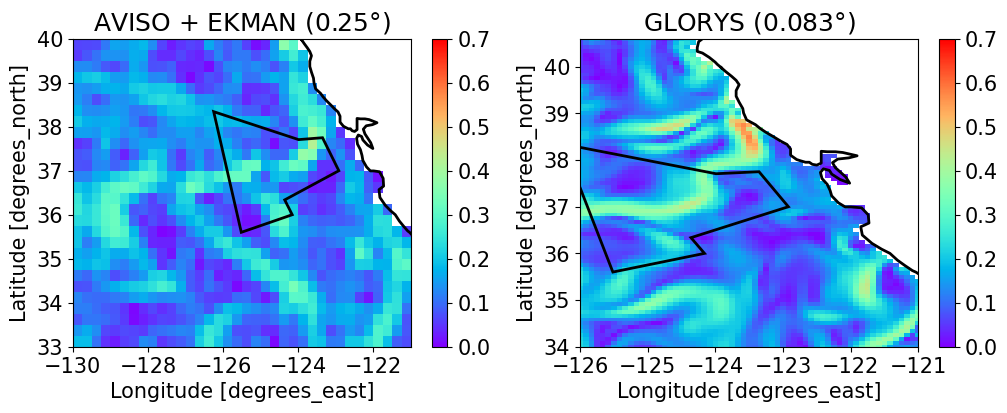

In [29]:
# Compare GLORYS to AVISO/COPERNICUS resolution

t0='2023-04-11'
fig, ax = plt.subplots(1,2,figsize=(12,4))
vmin,vmax=0,0.7
np.sqrt(u025**2+v025**2).sel(time=t0).plot(cmap='rainbow',vmin=vmin,vmax=vmax,ax=ax[0])
ax[0].plot(clon,clat,'-k',linewidth=2)
ax[0].set_title('AVISO + EKMAN (0.25$\degree$)')
smode_pgon(ax[0])

np.sqrt(u083**2+v083**2).sel(time='2023-04-11').plot(cmap='rainbow',vmin=vmin,vmax=vmax,ax=ax[1])
ax[1].plot(clon,clat,'-k',linewidth=2)
ax[1].set_title('GLORYS (0.083$\degree$)')
smode_pgon(ax[1])
ax[1].set_xlim(lonmin,lonmax); ax[1].set_ylim(latmin,latmax)

#plt.suptitle(f'Instanteneous Surface Current Amplitude {t0}',fontsize=18)
#plt.tight_layout()

#plt.savefig('diff.png',dpi=800)
plt.show();

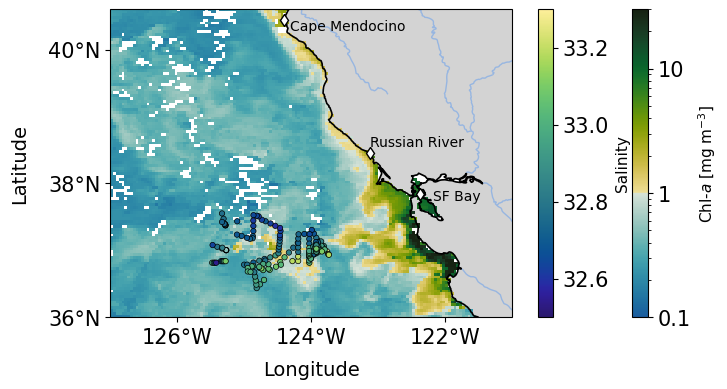

In [38]:
## Test out new color maps

# Set map extent
lonmin,lonmax,latmin,latmax = -127,-121,36,40.6
plt.rcParams['font.size'] = 15
t0 = btl_stn_dates # btl_stn_dates_fw # (fw = freshwater)
X_lon = btlstn_lons
X_lat = btlstn_lats

# Set up figure
fig, ax = plt.subplots(1,1,figsize=(8,4),subplot_kw={'projection': ccrs.PlateCarree()})

# Plot Chl-a values
pcm = ax.pcolormesh(
    chl.lon, chl.lat, chl.sel(time=t0[1]),
    # norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
    # cmap=no_white_cmap,
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Plot station markers
stns = ax.scatter(X_lon,X_lat,c=btl_IOP2.sal_abs,cmap=cmocean.cm.haline,s=15, vmin=32.5, vmax=33.3, edgecolors = "black",lw=0.5)

# Plot map features
cbar2 = plt.colorbar(stns);
cbar2.set_label('Salinity', fontsize=11)
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
# ax.set_title(dataset+' (%.3g$\degree$)'%res)

## Add ROI locations (Russian River and SF Bay)
RR = [38.450159, -123.130602] # Russian River
SF = [37.840524, -122.379691] # SF Bay
CM = [40.438594, -124.413537] # Cape Mendocino
ax.plot(RR[1],RR[0],'dw', markeredgecolor='k'); ax.text(RR[1],RR[0]+0.1,'Russian River',fontsize=10,color='k')
ax.plot(SF[1],SF[0],'dw', markeredgecolor='k'); ax.text(SF[1]+0.2,SF[0]-0.1,'SF Bay',fontsize=10,color='k')
ax.plot(CM[1],CM[0],'dw', markeredgecolor='k'); ax.text(CM[1]+0.1,CM[0]-0.15,'Cape Mendocino',fontsize=10,color='k')

add_latlon()

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# ax.text(0.05, 0.95, t0, transform=ax.transAxes, fontsize=11,
        #verticalalignment='top', bbox=props)
# ax.set_extent([-126, lonmax, 36, latmax], crs=ccrs.PlateCarree())
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
#smode_pgon(ax)

# Label for the bottom X-axis
ax.text(0.5, -0.2, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.25, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

# plt.savefig('map_surfbtlsamples_salinity_saved26Aug2026.png',dpi=600)

plt.show()

# print(transit_time)
# print(date_at_coast)

<>:82: SyntaxWarning: invalid escape sequence '\d'
<>:82: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k_/1rf2sqks5hz51srpqg10rhh00000gn/T/ipykernel_18072/1074686185.py:82: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(dataset+' (%.3g$\degree$)'%res)


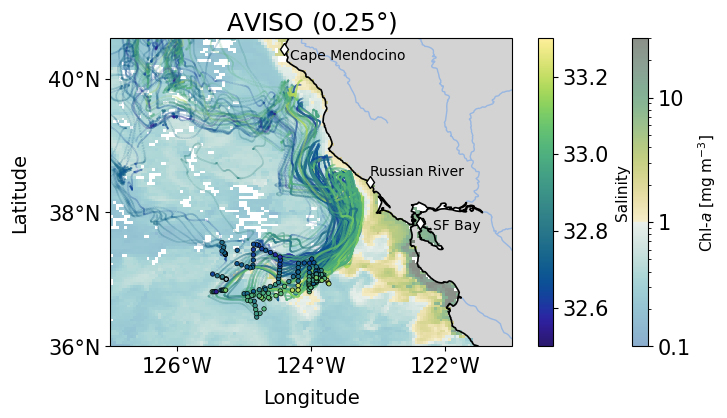

In [43]:
## GOAL: Track parcels sampled during surface-only bottle sampling during IOP-2
    ## Note: There are variable dates of sampling (t0 is not uniform)

# Load a cmocean colormap
# cmap = cmocean.cm.tempo

# Set map extent
lonmin,lonmax,latmin,latmax = -127,-121,36,40.6
plt.rcParams['font.size'] = 15

# Initialize sampling dates (t0 values)
t0 = btl_stn_dates # btl_stn_dates_fw # (fw = freshwater)

# Choose velocity data set 
dataset='AVISO'
if dataset=='GLORYS': u,v = u083, v083; cmap='Blues_r'; res=1/12
if dataset=='AVISO': u,v = u025, v025; cmap='Reds_r'; res=1/4    

# Intiialize lat and lon locations
X_lon = btlstn_lons
X_lat = btlstn_lats

# Set up figure
fig, ax = plt.subplots(1,1,figsize=(8,4),subplot_kw={'projection': ccrs.PlateCarree()})

# Plot Chl-a values
pcm = ax.pcolormesh(
    chl.lon, chl.lat, chl.sel(time=t0[1]),
    # norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
    # cmap=no_white_cmap,
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    alpha=0.5, # change transparency so trajectory lines are more visible.
    zorder=1
)

# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Compute particle backtracking
N = len(X_lat)
transit_time = []
date_at_coast = []

lat,lon = X_lat, X_lon

for i in range(N):
    #print(i)
    ## initialize particles where bottle samples took place.
    lat,lon = X_lat[i],X_lon[i]
    #print(lat,lon)
    u,v = u.sel(time=slice('2023-01-01',t0[i])), v.sel(time=slice('2023-01-01',t0[i]))
    lat_back, lon_back = particle_backtrack(lat,lon,u,v)
    
    transit_time.append(find_transit_time(v,lat_back,lon_back,dist_to_coast=res/2))
    t0_date = datetime.strptime(t0[i], '%Y-%m-%d')
    delta = timedelta(days=float(transit_time[i]))
    date_at_coast.append(t0_date - delta)
    
    ## plot tracks and initial points
    cmap=cmocean.cm.haline

    if transit_time[i]>0:
        smooth_lat, smooth_lon = smooth_track(lat_back[0:transit_time[i]],lon_back[0:transit_time[i]])
        sal_trajectory = btl_IOP2.sal_abs[i]
        # trajlines = ax.plot(smooth_lon, smooth_lat,color='k',linewidth=0.3)
        trajlines = ax.scatter(smooth_lon,smooth_lat,c=np.repeat(sal_trajectory,len(smooth_lon)),cmap=cmocean.cm.haline, s=0.005, vmin=32.5, vmax=33.3)


# Plot station markers
stns = ax.scatter(X_lon,X_lat,c=btl_IOP2.sal_abs,cmap=cmocean.cm.haline,s=10, vmin=32.5, vmax=33.3, edgecolors = "black", lw=0.5)

# Plot map features
cbar2 = plt.colorbar(stns);
cbar2.set_label('Salinity', fontsize=11)
ax.add_feature(cfeature.LAND,color='lightgrey')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
ax.set_title(dataset+' (%.3g$\degree$)'%res)

## Add ROI locations (Russian River and SF Bay)
RR = [38.450159, -123.130602] # Russian River
SF = [37.840524, -122.379691] # SF Bay
CM = [40.438594, -124.413537] # Cape Mendocino
ax.plot(RR[1],RR[0],'dw', markeredgecolor='k'); ax.text(RR[1],RR[0]+0.1,'Russian River',fontsize=10,color='k')
ax.plot(SF[1],SF[0],'dw', markeredgecolor='k'); ax.text(SF[1]+0.2,SF[0]-0.1,'SF Bay',fontsize=10,color='k')
ax.plot(CM[1],CM[0],'dw', markeredgecolor='k'); ax.text(CM[1]+0.1,CM[0]-0.15,'Cape Mendocino',fontsize=10,color='k')

add_latlon()

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# ax.text(0.05, 0.95, t0, transform=ax.transAxes, fontsize=11,
        #verticalalignment='top', bbox=props)
# ax.set_extent([-126, lonmax, 36, latmax], crs=ccrs.PlateCarree())
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
#smode_pgon(ax)

# Label for the bottom X-axis
ax.text(0.5, -0.18, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.25, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

# plt.savefig(f'{dataset}_backtrack_surfbtlsamples_saved26Aug2026.png',dpi=600,bbox_inches='tight', pad_inches=0)

plt.show()

# print(transit_time)
# print(date_at_coast)

<>:86: SyntaxWarning: invalid escape sequence '\d'
<>:86: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k_/1rf2sqks5hz51srpqg10rhh00000gn/T/ipykernel_18072/3975234870.py:86: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title(dataset+' (%.3g$\degree$)'%res)


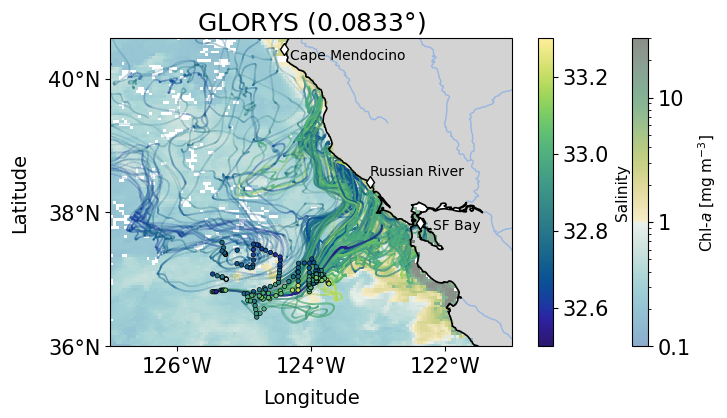

In [42]:
## GOAL: Track parcels sampled during surface-only bottle sampling during IOP-2
    ## Note: There are variable dates of sampling (t0 is not uniform)

# Load a cmocean colormap
# cmap = cmocean.cm.tempo

# Set map extent
lonmin,lonmax,latmin,latmax = -127,-121,36,40.6
plt.rcParams['font.size'] = 15

# Initialize sampling dates (t0 values)
t0 = btl_stn_dates # btl_stn_dates_fw # (fw = freshwater)

# Choose velocity data set 
dataset='GLORYS'
if dataset=='GLORYS': u,v = u083, v083; cmap='Blues_r'; res=1/12
if dataset=='AVISO': u,v = u025, v025; cmap='Reds_r'; res=1/4    

# Intiialize lat and lon locations
X_lon = btlstn_lons
X_lat = btlstn_lats

# Set up figure
fig, ax = plt.subplots(1,1,figsize=(8,4),subplot_kw={'projection': ccrs.PlateCarree()})

# Plot Chl-a values
pcm = ax.pcolormesh(
    chl.lon, chl.lat, chl.sel(time=t0[1]),
    # norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
    # cmap=no_white_cmap,
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    zorder=1,
    alpha=0.5 # change transparency so trajectory lines are more visible.
)

# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Compute particle backtracking
N = len(X_lat)
transit_time = []
date_at_coast = []

lat,lon = X_lat, X_lon

for i in range(N):
    #print(i)
    ## initialize particles where bottle samples took place.
    lat,lon = X_lat[i],X_lon[i]
    #print(lat,lon)
    u,v = u.sel(time=slice('2023-01-01',t0[i])), v.sel(time=slice('2023-01-01',t0[i]))
    lat_back, lon_back = particle_backtrack(lat,lon,u,v)
    
    transit_time.append(find_transit_time(v,lat_back,lon_back,dist_to_coast=res/2))
    t0_date = datetime.strptime(t0[i], '%Y-%m-%d')
    delta = timedelta(days=float(transit_time[i]))
    date_at_coast.append(t0_date - delta)
    
    ## plot tracks and initial points

    if transit_time[i]>0:
        smooth_lat, smooth_lon = smooth_track(lat_back[0:transit_time[i]],lon_back[0:transit_time[i]])
        sal_trajectory = btl_IOP2.sal_abs[i]
        # trajlines = ax.plot(smooth_lon, smooth_lat,color='k',linewidth=0.3)
        # if 32.6 <= sal_trajectory <= 33.3:
        #     backgroundlines = ax.scatter(smooth_lon,smooth_lat,color="white",s=0.0075)
        trajlines = ax.scatter(smooth_lon,smooth_lat,c=np.repeat(sal_trajectory,len(smooth_lon)),cmap=cmocean.cm.haline, s=0.005, vmin=32.5, vmax=33.3)
        # trajlines_wEdge = ax.scatter(smooth_lon,smooth_lat,c=np.repeat(sal_trajectory,len(smooth_lon)),
        #                              cmap=cmocean.cm.haline, s=0.005, vmin=32.5, vmax=33.3, 
        #                              edgecolors = "black", lw=0.5)


# Plot station markers
stns = ax.scatter(X_lon,X_lat,c=btl_IOP2.sal_abs,cmap=cmocean.cm.haline,s=10, vmin=32.5, vmax=33.3, edgecolors = "black", lw=0.5)

# Plot map features
cbar2 = plt.colorbar(stns);
cbar2.set_label('Salinity', fontsize=11)
ax.add_feature(cfeature.LAND,color='lightgrey')
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
ax.set_title(dataset+' (%.3g$\degree$)'%res)

## Add ROI locations (Russian River and SF Bay)
RR = [38.450159, -123.130602] # Russian River
SF = [37.840524, -122.379691] # SF Bay
CM = [40.438594, -124.413537] # Cape Mendocino
ax.plot(RR[1],RR[0],'dw', markeredgecolor='k'); ax.text(RR[1],RR[0]+0.1,'Russian River',fontsize=10,color='k')
ax.plot(SF[1],SF[0],'dw', markeredgecolor='k'); ax.text(SF[1]+0.2,SF[0]-0.1,'SF Bay',fontsize=10,color='k')
ax.plot(CM[1],CM[0],'dw', markeredgecolor='k'); ax.text(CM[1]+0.1,CM[0]-0.15,'Cape Mendocino',fontsize=10,color='k')

add_latlon()

props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# ax.text(0.05, 0.95, t0, transform=ax.transAxes, fontsize=11,
        #verticalalignment='top', bbox=props)
# ax.set_extent([-126, lonmax, 36, latmax], crs=ccrs.PlateCarree())
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
#smode_pgon(ax)

# Label for the bottom X-axis
ax.text(0.5, -0.18, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.25, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

plt.savefig(f'{dataset}_backtrack_surfbtlsamples_saved26Aug2026.png',dpi=600,bbox_inches='tight', pad_inches=0)

plt.show()

# print(transit_time)
# print(date_at_coast)